# Evaluating Agentic App developed using Langgraph with IBM Watsonx Models: Advanced Capabilities with IBM watsonx.governance

This notebook demonstrates advanced evaluation capabilities of IBM watsonx.governance for monitoring and governing production-grade LangGraph agentic systems. Using an Agentic RAG implementation that orchestrates IBM Granite model's **ibm/granite-3-2-8b-instruct** and **ibm/slate-30m-english-rtrvr-v2** through LangGraph workflows, we showcase how to use different evaluators in development environment. These evaluators provide enterprise-ready governance for complex agentic architectures, moving beyond basic LLM assessments.

## Key Components

### Models Used
- **Text Generation**: `ibm/granite-3-2-8b-instruct` - IBM's Granite 3.2 8B instruction-tuned model for high-quality text generation
- **Embeddings**: `ibm/slate-30m-english-rtrvr-v2` - IBM's SLATE 30M retrieval model for semantic search and document embeddings

### Architecture
- **Framework**: LangGraph for orchestrating multi-step agentic workflows
- **Vector Store**: Chroma for efficient similarity search
- **Governance**: IBM watsonx.governance for comprehensive evaluation and monitoring

### Evaluation Capabilities
- **Retrieval Quality Metrics**: Context relevance evaluation for RAG systems
- **Answer Quality Metrics**: Answer relevance and correctness assessment
- **Content Safety**: Automated safety checks for generated content
- **Node-Level Monitoring**: Granular evaluation at each workflow step
- **Interaction-Level Metrics**: End-to-end performance assessment



### Install the dependencies

In [ ]:
%pip install --quiet "ibm-watsonx-gov[agentic,visualization]" 

In [ ]:
%pip install  --quiet "langchain-chroma>=1.0.0,<1.2.0" "langchain-openai>=1.1.0,<1.2.0" "langgraph>=0.3.34,<1.2.0" ddgs 

In [ ]:
%pip install --quiet "ibm_watsonx_ai"

In [ ]:
%pip install --quiet "setuptools==70.0.0"

**Note**: If you encounter any Torch-related attribute errors while setting up the evaluator, try resolving them by running the cell below to uninstall Torch. This step is required when running in Watson Studio.

In [ ]:
# %pip uninstall -y torch torchvision torchaudio

### Runtime-specific Python library updates and rebuilds

#### For Runtime 24.1
If you are running the notebook in the Runtime 24.1 environment, uncomment the below cell. It force-reinstalls certain Python packages to ensure they are rebuilt or upgraded for compatibility with NumPy 2.x.

In [ ]:
#%pip install --quiet --upgrade --force-reinstall --no-cache-dir "ibm-agent-analytics<0.6.0" chromadb tensorflow "transformers<4.54.0" numexpr bottleneck opencv-python pyarrow-hotfix

#### For Runtime 25.1
If you are running the notebook in Runtime 25.1 environment, uncomment the below cells. The following cells installs `pysqlite3-binary` and configures it as the default `sqlite3`, overriding the older system-managed version. 

In [ ]:
# %pip install --upgrade --force-reinstall --no-cache-dir pysqlite3-binary

In [ ]:
# import sys
# import pysqlite3

# # replace stdlib sqlite3 with pysqlite3
# sys.modules["sqlite3"] = pysqlite3

### Accept the credentials
The following code snippet ensures that specific environment variables are set without being hardcoded in the script. It does so by prompting the user for input only if the variables are not already set.

The environment variable need to be set:

For watsonx.governance Cloud
1. **WATSONX_APIKEY:** This is required for IBM watsonx.governance capabilities. Your Cloud API key can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below.
2. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one watsonx.governance instance.
3. **WATSONX_REGION** [Optional]: Set if you are using IBM watsonx.governance as a service in a regional data center other than default **Dallas (us-south), in Texas US**. Supported region values are "us-south", "eu-de", "au-syd", "ca-tor", "jp-tok", "eu-gb".

For watsonx.governance OnPrem
1. **WATSONX_URL** : The CPD cluster URL.
2. **WATSONX_USERNAME** : The CPD username.
3. **WATSONX_PASSWORD** [Optional] : The CPD password.
4. **WATSONX_APIKEY** [Optional] : The CPD API key. Either WATSONX_APIKEY or WATSONX_PASSWORD is required for CPD authentication.
5. **WATSONX_VERSION** : The version of CPD.
6. **WATSONX_DISABLE_SSL** [Optional]: Set to true if you want to disable SSL.
7. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one datamart

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


# For watsonx.governance Cloud
_set_env("WATSONX_APIKEY")
# _set_env("WATSONX_REGION")
_set_env("WXG_SERVICE_INSTANCE_ID")
_set_env("WXG_PROJECT_ID")


# For watsonx.governance on-prem
# _set_env("WATSONX_URL")
# _set_env("WATSONX_USERNAME")
# # _set_env("WATSONX_APIKEY")
# _set_env("WATSONX_PASSWORD") # Only one of apikey and password should be specified.
# # _set_env("WATSONX_VERSION")
# _set_env("WATSONX_DISABLE_SSL")  # Set to true if you want to disable SSL
# _set_env("WXG_SERVICE_INSTANCE_ID") # To specify a governance instance id if more than one exist

### Set up the local vector store

We have created a local vector store comprising of a few medium posts by [Manish Bhide](https://medium.com/@manish.bhide) and [Ravi Chamarthy](https://medium.com/@ravi-chamarthy). These posts focus on the various capabilities in IBM watsonx.governance (and erstwhile IBM Watson OpenScale). Hence, our queries will focus on these capabilities covered in the above posts. 

For user's convenience, the vector store has been compressed. The following cells download the compressed file, extract it locally, create the IBM watsonx embedding model, and initialize the Chroma store with the watsonx embeddings. 

This notebook uses **IBM SLATE 30M English Retriever v2** (`ibm/slate-30m-english-rtrvr-v2`) as the embedding model for the vector store. The model is wrapped in a LangChain-compatible interface (`IBMGraniteEmbeddings`) to work with the Chroma vector store.

In [ ]:
%rm medium_db.zip
%rm -r medium_db/

!wget https://github.com/IBM/ibm-watsonx-gov/raw/refs/heads/samples/notebooks/data/agentic/medium_db.zip

In [3]:
import zipfile

with zipfile.ZipFile("medium_db.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [4]:

from langchain_chroma import Chroma
from ibm_watsonx_ai import Credentials

from ibm_watsonx_ai.foundation_models import Embeddings


creds = Credentials(
    url="https://us-south.ml.cloud.ibm.com",   
    api_key=os.environ.get("WATSONX_APIKEY")
     
)

# Create the embedding model
granite_embedder = Embeddings(
    model_id="ibm/slate-30m-english-rtrvr-v2",
    credentials=creds,
    project_id=os.environ.get("WXG_PROJECT_ID"),
)



In [6]:
from langchain.embeddings.base import Embeddings as LCEmbeddings

class IBMGraniteEmbeddings(LCEmbeddings):
    def __init__(self, granite_model):
        self.granite_model = granite_model

    def embed_documents(self, texts):
        return self.granite_model.embed_documents(texts)

    def embed_query(self, text):
        return self.granite_model.embed_documents([text])[0]


In [7]:
import shutil

# Delete the old persistent folder
shutil.rmtree("./medium_db", ignore_errors=True)

ibm_embedder = IBMGraniteEmbeddings(granite_embedder)

vector_store = Chroma(
    collection_name="medium_articles",
    embedding_function=ibm_embedder,   
    persist_directory="./medium_db"
)

### Set up the State

In [8]:
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        input_text (str): 
            The user's raw input query or question. 
        ground_truth (Optional[str]): 
            Reference/correct answer (if available). Used for evaluation.           
        local_context (List[str]): 
            Context retrieved from local knowledge base or vector store. 
        web_context (List[str]): 
            Context fetched from web searches (if used). 
        generated_text (Optional[str]): 
            The final output generated by the LLM after processing all contexts.
    """
    input_text: str #The user's raw input query or question
    ground_truth: str #Reference/correct answer (if available). Used for evaluation
    local_context: list[str] #Context retrieved from vector store
    web_context: list[str] #Context fetched from web searches (if used)
    generated_text: str #The final output generated by the LLM after processing all contexts

### Set up the evaluator

For evaluating your Agentic AI applications, you need to first instantiate the `AgenticEvaluator` class. This class defines evaluators to compute the different metrics at the node and interaction level.

We are going to use the following evaluator group in this notebook:
1. `evaluate_retrieval_quality` : To compute retrieval quality metrics on your content retrieval tool. Retrieval Quality metrics include Context Relevance, Retrieval Precision, Average Precision, Hit Rate, Reciprocal Rank, NDCG
2. `evaluate_answer_quality`: To compute answer quality metric of your answer generation tool. Answer Quality metrics include Answer Relevance, Faithfulness, Answer Similarity, Unsuccessful Requests. Answer Similarity metric requires ground truth. 

#### Configuring Evaluations

You can define the `AgenticApp` class to define the interaction, node metrics to be computed.

You can define the metrics to be computed at the agentic app(interaction) level in metrics_configuration in `AgenticApp`.
You can specify the node level metrics to be computed along with the graph invocation using the decorators on the function.
You can specify the node level metrics to be computed after with the graph invocation using the decorators and with flag `compute_real_time` set to False or specify in the `nodes` attribute in `AgenticApp`, but it's recommended to use only one of these approaches to avoid conflicts or redundancy.

You can define evaluation configurations by specifying relevant fields for different evaluation types, such as retrieval quality and answer quality.

For example, a configuration for evaluating retrieval quality might look like this:  

```python
retrieval_quality_config = {
    "input_fields": ["input_text"], 
    "context_fields": ["local_context"]
}
```

This configuration is then used to create an `AgenticAIConfiguration` instance.

In [ ]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.entities.agentic_app import (AgenticApp, MetricsConfiguration, Node)
from ibm_watsonx_gov.metrics import AnswerRelevanceMetric, ContextRelevanceMetric
from ibm_watsonx_gov.entities.enums import MetricGroup

# Define the metrics to be computed at the agentic app(interaction) level in metrics_configuration under AgenticApp, these metrics use the agent input and output fields.
# The node level metrics to be computed after the graph invocation can be specified
retrieval_quality_config_web_search_node = {
    "input_fields": ["input_text"],
    "context_fields": ["web_context"]
}

nodes = [Node(name="Web \nSearch \nNode",
              metrics_configurations=[MetricsConfiguration(configuration=AgenticAIConfiguration(**retrieval_quality_config_web_search_node),
                                                           metrics=[ContextRelevanceMetric()])])]

agent_app = AgenticApp(name="Rag agent",
                       metrics_configuration=MetricsConfiguration(metrics=[
                           AnswerRelevanceMetric()],
                           metric_groups=[MetricGroup.CONTENT_SAFETY]),
                       nodes=nodes)

evaluator = AgenticEvaluator(agentic_app=agent_app)

### [Optional] Set up LLM Judge for metrics evaluation

For using LLM as judge when evaluating metrics, you need to define the model provider and the model name along with the needed credentials. The metrics that support evaluation using LLM judge are 
`context_relevance`, `faithfulness`, `answer_relevance` and `answer_similarity`.

To use LLM judge to evaluate a metric you need to add the details of the `llm_judge` when creating the metric object. For example:

```python
# Define LLM Judge using watsonx.ai
llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="ibm/granite-3-3-8b-instruct",
        project_id="<PROJECT_ID>",
    )
)



# Specify the LLM judge when initializing the metric
@evaluator.evaluate_context_relevance(
    configuration=AgenticAIConfiguration(**context_relevance_config_local_search_node),
    metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
)

In [10]:
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge

_set_env("WXG_PROJECT_ID")
PROJECT_ID = os.getenv("WXG_PROJECT_ID")

llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="ibm/granite-3-3-8b-instruct",
        project_id=PROJECT_ID,
    )
)

### Build your langgraph application

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langgraph.config import RunnableConfig

#### Define vector database retrieval node

We are using a Similarity with Threshold Retrieval strategy. This will fetch the top 3 documents matching the query if the threshold score is more than 0.1

The `local_search_node` tool defined below is decorated with IBM watsonx.governance evaluator group `evaluate_retrieval_quality` tool to compute the retrieval quality metrics. Retrieval Quality metrics include Context Relevance, Retrieval Precision, Average Precision, Hit Rate, Reciprocal Rank, NDCG. Users can use the individual metrics by decorating the individual evaluators (`evaluate_retrieval_precision`, `evaluate_average_precision`, `evaluate_hit_rate`, `evaluate_reciprocal_rank`, `evaluate_ndcg`, `evaluate_context_relevance`) . This node reads the user query from the `input_text` attribute from the application state and writes the result into the `local_context` attribute back to the application state.

In [12]:
from ibm_watsonx_gov.metrics import ContextRelevanceMetric

retrieval_quality_config_local_search_node = {
    "input_fields": ["input_text"],
    "context_fields": ["local_context"],
}


@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(
        **retrieval_quality_config_local_search_node),
    # Uncomment the following line to evaluate context relevance using LLM as judge
    # metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
)
# @evaluator.evaluate_retrieval_precision(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
# @evaluator.evaluate_average_precision(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
# @evaluator.evaluate_hit_rate(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
# @evaluator.evaluate_reciprocal_rank(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
# @evaluator.evaluate_ndcg(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
# @evaluator.evaluate_context_relevance(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
def local_search_node(state: GraphState, config: RunnableConfig) -> dict:
    similarity_threshold_retriever = vector_store.as_retriever(search_type="similarity_score_threshold",
                                                               search_kwargs={"k": 3,
                                                                              "score_threshold": 0.1})
    context = similarity_threshold_retriever.invoke(state["input_text"])
    return {
        "local_context": [doc.page_content for doc in context]
    }

#### Define web search retrieval node

We are using a DuckDuckGo to do the web search.

The `web_search_node` tool defined below is decorated with IBM watsonx.governance evaluator group `evaluate_retrieval_quality` tool to compute the retrieval quality metrics. Retrieval Quality metrics include Context Relevance, Retrieval Precision, Average Precision, Hit Rate, Reciprocal Rank, NDCG. Users can use the individual metrics by decorating the individual evaluators as mentioned above. This node reads the user query from the `input_text` attribute from the application state and writes the result into the `web_context` attribute back to the application state.

In [18]:
from ddgs import DDGS
ddg = DDGS()


retrieval_quality_config_web_search_node = {
    "input_fields": ["input_text"],
    "context_fields": ["web_context"],
}


@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(
        **retrieval_quality_config_web_search_node),
    # Uncomment the following line to evaluate context relevance using LLM as judge
    # metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
)

def web_search_node(state: dict, max_results: int = 5) -> dict:
    """Perform web search and return relevant content snippets """
    query = state["input_text"]

    # Perform web search
    with DDGS() as ddg:
        search_data = list(ddg.text(query, max_results=max_results))


    search_result = {
        "answer": None,  # DuckDuckGo doesn't provide direct answers
        "results": []
    }

    for r in search_data:
        search_result["results"].append({
            "url": r.get("href"),
            "content": r.get("body"),
            "title": r.get("title")
        })

    results = []
    if search_result.get("answer"):
        results.append(f"Direct answer: {search_result['answer']}")

    for result in search_result.get("results", [])[:max_results]:
        if content := result.get("content"):
            results.append(f"From {result['url']}: {content}")

    return {
        "web_context": results[:max_results]
    }


#### Define vector-database based answer generation tool

We are using `gpt-4o-mini` to generate an answer for our query.

The `generate_local_context_node` defined below is decorated with evaluator group `evaluate_answer_quality` for computing answer quality metrics. Answer Quality metrics include Answer Relevance, Faithfulness, Answer Similarity, Unsuccessful Requests. Like in the previous cell, this node reads the user query from the `input_text` attribute from the application state, the `context` attribute consists of the context chunks. After generating the answer, the node writes the result into the `generated_text` attribute back to the application state. Users can use the individual metrics by decorating the individual evaluators as mentioned above. Similar to retrieval quality metrics in the previous cell, answer quality metrics can be evaluated using LLM as judge.

In [19]:
from ibm_watsonx_gov.metrics import FaithfulnessMetric
from ibm_watsonx_ai.foundation_models import ModelInference

answer_quality_config_local_context_node={
    "input_fields": ["input_text"], 
    "context_fields": ["local_context"], 
    "output_fields": ["generated_text"],
    "reference_fields":["ground_truth"]
}


@evaluator.evaluate_answer_quality(
    configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node),
    # Uncomment the following block evaluate the faithfulness metric using LLM judge
    # metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
)
# @evaluator.evaluate_faithfulness(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
# @evaluator.evaluate_answer_similarity(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
# @evaluator.evaluate_answer_relevance(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
# @evaluator.evaluate_unsuccessful_requests(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
def generate_local_context_node(state: GraphState, config: RunnableConfig) -> dict:
    generate_prompt = ChatPromptTemplate.from_template(
        "Answer the query using only the provided context:\n"
        "Context: {context}\n"
        "Question: {input_text}\n"
        "Answer:"
    )

    prompt_text = generate_prompt.invoke(
        {"input_text": state["input_text"], "context": "\n".join(state["web_context"])})
    formatted_prompt = prompt_text.to_string() 
    llm = ModelInference(
        model_id="ibm/granite-3-2-8b-instruct", 
        credentials=creds,
        params={
            "max_new_tokens": 512,
            "temperature": 0.3
        },
        project_id= os.getenv("WXG_PROJECT_ID")
    )
    result = llm.generate(formatted_prompt)
    return {
        "generated_text": result['results'][0]['generated_text']
    }

#### Define web-search based answer generation tool

We are using `ibm/granite-3-2-8b-instruct` to generate an answer for our query.

The `generate_web_context_node` defined below is decorated with with evaluator group `evaluate_answer_quality` for computing answer quality metrics. Answer Quality metrics include Answer Relevance, Faithfulness, Answer Similarity, Unsuccessful Requests. Like in the previous cell, this node reads the user query from the `input_text` attribute from the application state, the `context` attribute consists of the context chunks. After generating the answer, the node writes the result into the `generated_text` attribute back to the application state. Users can use the individual metrics by decorating the individual evaluators as mentioned above.

In [20]:
answer_quality_config_local_context_node={
    "input_fields": ["input_text"], 
    "context_fields": ["web_context"], 
    "output_fields": ["generated_text"],
    "reference_fields":["ground_truth"]
}

@evaluator.evaluate_answer_quality(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
def generate_web_context_node(state: GraphState, config: RunnableConfig) -> dict:
    generate_prompt = ChatPromptTemplate.from_template(
        "Answer the query using web-sourced information:\n"
        "Context: {context}\n"
        "Question: {input_text}\n"
        "Answer:"
    )

    prompt_text = generate_prompt.invoke(
        {"input_text": state["input_text"], "context": "\n".join(state["web_context"])})
    formatted_prompt = prompt_text.to_string() 

    llm = ModelInference(
        model_id="ibm/granite-3-2-8b-instruct", 
        credentials=creds,
        params={
            "max_new_tokens": 512,
            "temperature": 0.3
        },
        project_id= os.getenv("WXG_PROJECT_ID")
    )
    result = llm.generate(formatted_prompt)
    return {
        
        "generated_text": result['results'][0]['generated_text']
    }

#### Adding a Router Function to Check Context Relevance

- The `check_context_relevance` function evaluates the retrieved context and assigns a **Context Relevance Score**.  
- If the score meets the required threshold, the workflow proceeds to the **Vector DB Answer Generation** node.  
- If the score is below the threshold, the workflow reroutes to the **Web Search Node** for additional information.  

In [21]:
def check_context_relevance(state: GraphState, config: RunnableConfig) -> str:

    # Filter results for "context_relevance" from the "retrieval_node"
    latest_metric = evaluator.get_metric_result(
        metric_name="context_relevance", node_name="local_search_node")

    if not latest_metric:
        # Default to "no" if no metrics found
        return "Context Relevance \nScore is Bad"
    
    # Check if context relevance is below threshold
    if latest_metric.value > 0.5:
        return "Context Relevance \nScore is Good"
    else:
        return "Context Relevance \nScore is Bad"

#### Assemble your application

In [22]:
from langgraph.graph import START, END, StateGraph

graph = StateGraph(GraphState)

# Add nodes
graph.add_node("Vector DB \nRetrieval \nNode", local_search_node)
graph.add_node("Web \nSearch \nNode", web_search_node)
graph.add_node("Vector DB \nAnswer \nGeneration", generate_local_context_node)
graph.add_node("Web Search \nAnswer \nGeneration", generate_web_context_node)

# Add edges
graph.add_edge(START, "Vector DB \nRetrieval \nNode")
graph.add_conditional_edges(
    "Vector DB \nRetrieval \nNode",
    check_context_relevance,
    {
        "Context Relevance \nScore is Good": "Vector DB \nAnswer \nGeneration",
        "Context Relevance \nScore is Bad": "Web \nSearch \nNode",
    },
)
graph.add_edge("Web \nSearch \nNode", "Web Search \nAnswer \nGeneration")
graph.add_edge("Vector DB \nAnswer \nGeneration", END)
graph.add_edge("Web Search \nAnswer \nGeneration", END)

# Compile the graph
rag_app = graph.compile()

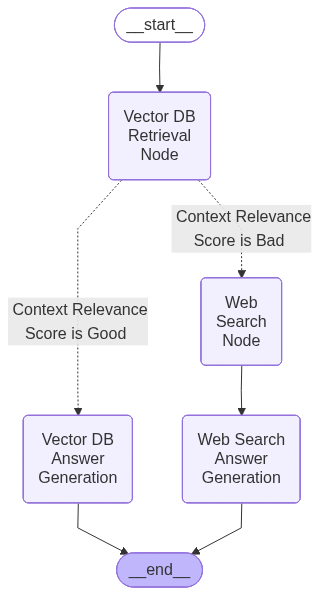

In [23]:
from langchain_core.runnables.graph import MermaidDrawMethod

image = rag_app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

from IPython.display import Image, display
display(Image(data=image))

### Do a single invocation

Now the application is invoked for a single row of data. You will see a new key as the input:

`ground_truth`: As the name suggests, this attribute holds the ground truth for your input text. This is needed for the answer similarity metric, which is a reference based metric. For the other metrics, this is not required.

In [ ]:
evaluator.start_run()
result = rag_app.invoke({"input_text": "What is concept drift?", "ground_truth": "Concept drift occurs when the statistical properties of the target variable change over time, causing a machine learning model’s predictions to become less accurate.", "record_id":"764545"})
evaluator.end_run()

### Prepare the app results

In [25]:
eval_result = evaluator.get_result()
metric_result = eval_result.to_df()

### Display the metric results

In [ ]:
from IPython.display import display

display(metric_result)

#### Get Metric Results for a specific node

In [27]:
eval_result.get_aggregated_metrics_results(node_name="Web \nSearch \nNode")

[{'name': 'context_relevance',
  'display_name': 'Context Relevance',
  'value_type': 'numeric',
  'method': 'token_precision',
  'provider': 'unitxt',
  'value': 0.75,
  'group': 'retrieval_quality',
  'thresholds': [{'type': 'lower_limit', 'value': 0.7}],
  'min': 0.75,
  'max': 0.75,
  'percentiles': {'25': 0.75,
   '50': 0.75,
   '75': 0.75,
   '90': 0.75,
   '95': 0.75,
   '99': 0.75},
  'count': 2,
  'node_name': 'Web \nSearch \nNode',
  'applies_to': 'node',
  'individual_results': [{'name': 'context_relevance',
    'display_name': 'Context Relevance',
    'value_type': 'numeric',
    'method': 'token_precision',
    'provider': 'unitxt',
    'value': 0.75,
    'additional_info': {'contexts_values': [0.75]},
    'group': 'retrieval_quality',
    'thresholds': [{'type': 'lower_limit', 'value': 0.7}],
    'applies_to': 'node',
    'message_id': 'Z6nDeHxlweWC4uZi9yi0+g==',
    'conversation_id': 'Z6nDeHxlweWC4uZi9yi0+g==',
    'node_name': 'Web \nSearch \nNode',
    'execution_coun

### Invoke the graph on multiple rows

IBM watsonx.governance evaluation of Agentic Applications can be done with batch invocation too. Here, a dataframe with questions and ground truths for those questions have been defined. 

In [ ]:
import pandas as pd

question_bank_df = pd.read_csv("https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/refs/heads/samples/notebooks/data/agentic/watsonx_governance_question_bank.csv")
question_bank_df

#### Rate Limit Handling for multiple rows

In [ ]:
from logging import exception
import time

def rate_limit_handling_multiple_records(inputs, max_retries=5, chunk_size=2):
    """
    Call rag_app.batch safely with rate-limit handling.
    """
    results = []
    for i in range(0, len(inputs), chunk_size):
        chunk = inputs[i:i + chunk_size]
        attempt = 0
        while attempt < max_retries:
            try:
                results.extend(rag_app.batch(chunk))
                break  
            except Exception as e:
                if e.status_code == 429:
                    wait_time = 2 ** attempt  
                    print(f"Rate limit hit, waiting {wait_time}s before retry...")
                    time.sleep(wait_time)
                    attempt += 1
                else:
                    raise
        else:
            raise Exception("Max retries exceeded for batch call")
    return results


In [ ]:
evaluator.start_run()
records = question_bank_df.to_dict("records")
result =  rate_limit_handling_multiple_records(records)
evaluator.end_run()


In [ ]:
result_df = pd.DataFrame(result)
input_data = result_df[["input_text"]] # Add the columns which should be part of the application metric results
eval_result = evaluator.get_result()
metric_result = eval_result.to_df()
result_with_data=pd.concat([input_data, metric_result], axis=1)

display(result_with_data)

Developed by [Thara Basheer](https://ibm.enterprise.slack.com/team/U03A5MXCDMH)